# Projectile motion with air resistance

**Physics HL - Theme A**

The textbook parabola assumes no drag. With $F_{drag} = k v^2$ the range
shrinks, the path becomes asymmetric, and the best launch angle drops below
45 degrees.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

G = 9.81          # m s^-2
MASS = 0.145      # kg (a baseball)
DRAG_K = 0.0013   # F_drag = k * v^2
DT = 0.001        # s

## The simulation

Euler integration: update velocity from the forces, then position from the velocity, one small step at a time.

In [2]:
def simulate(speed, angle_deg, drag_k):
    theta = np.radians(angle_deg)
    vx, vy = speed * np.cos(theta), speed * np.sin(theta)
    x, y = 0.0, 0.0
    xs, ys = [x], [y]

    while y >= 0.0:
        v = np.hypot(vx, vy)
        ax = -drag_k * v * vx / MASS
        ay = -G - drag_k * v * vy / MASS
        vx += ax * DT
        vy += ay * DT
        x += vx * DT
        y += vy * DT
        xs.append(x)
        ys.append(y)

    return np.array(xs), np.array(ys)

## Trajectories

Dashed = vacuum, solid = with drag.

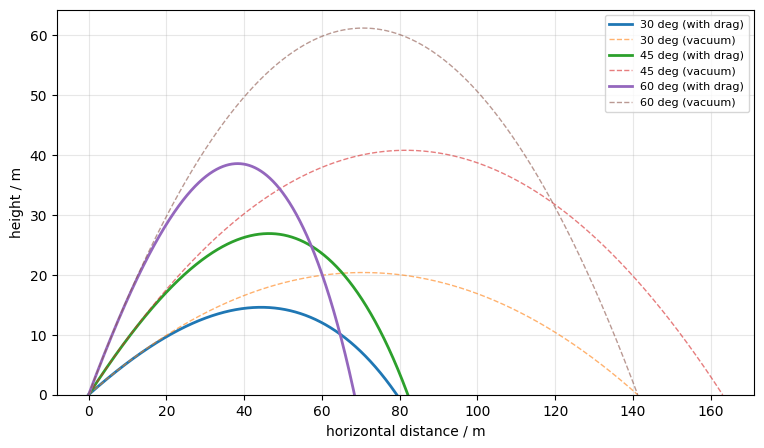

In [3]:
speed = 40.0  # m/s

fig, ax = plt.subplots(figsize=(9, 5))
for angle in (30, 45, 60):
    x, y = simulate(speed, angle, DRAG_K)
    ax.plot(x, y, lw=2, label=f"{angle} deg (with drag)")
    x0, y0 = simulate(speed, angle, 0.0)
    ax.plot(x0, y0, lw=1, ls="--", alpha=0.6, label=f"{angle} deg (vacuum)")

ax.set_xlabel("horizontal distance / m")
ax.set_ylabel("height / m")
ax.set_ylim(bottom=0)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

## Where does the optimum angle actually sit?

vacuum optimum:    45 deg
with drag optimum: 40 deg


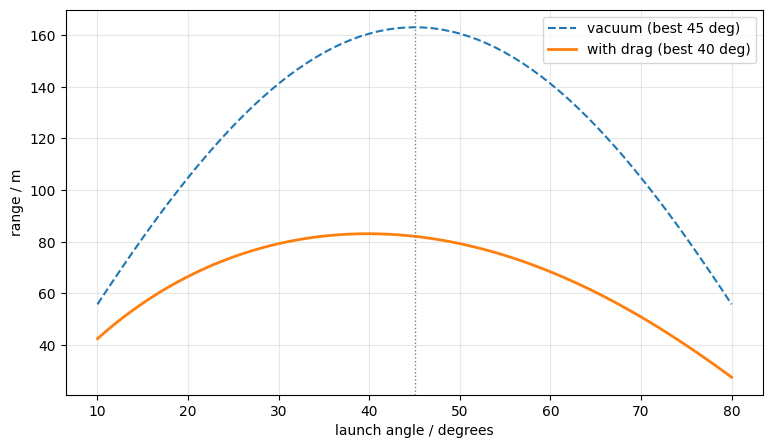

In [4]:
def best_angle(speed, drag_k):
    angles = np.arange(10, 81, 1)
    ranges = np.array([simulate(speed, a, drag_k)[0][-1] for a in angles])
    return angles[int(np.argmax(ranges))], angles, ranges


opt_drag, angles, ranges_drag = best_angle(speed, DRAG_K)
opt_vac, _, ranges_vac = best_angle(speed, 0.0)

print(f"vacuum optimum:    {opt_vac} deg")
print(f"with drag optimum: {opt_drag} deg")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(angles, ranges_vac, ls="--", label=f"vacuum (best {opt_vac} deg)")
ax.plot(angles, ranges_drag, lw=2, label=f"with drag (best {opt_drag} deg)")
ax.axvline(45, color="grey", ls=":", lw=1)
ax.set_xlabel("launch angle / degrees")
ax.set_ylabel("range / m")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Try changing

- `speed` - push it to 80 m/s and the optimum drops further.
- `DRAG_K = 0` recovers the textbook result exactly.
- `DT` - make it 0.05 and compare. Big steps drift, which is why step size
  matters in any numerical method.